# Pandas 실습 2

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd

In [8]:
# 데이터 로드
df = pd.read_csv('data/서울특별시 공공자전거 이용정보(일별)_2512.csv', encoding='cp949')

In [49]:
df.head()

,대여일자,대여소번호,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2025-12-01,736,736. 오솔길공원,정기권,NaN,~10대,1,19.83,0.26,1113.03,17
1,2025-12-01,1033,1033. 고덕동 아남아파트,정기권,NaN,~10대,1,48.47,0.44,1882.99,11
2,2025-12-01,1964,1964. 원메디타운 앞,정기권,NaN,~10대,1,7.80,0.11,492.38,5
3,2025-12-01,1160,1160. 양천향교역 7번출구앞,정기권,NaN,~10대,1,11.94,0.13,548.38,5
4,2025-12-01,3516,3516. 구의아리수정수센터앞,정기권,NaN,~10대,1,42.08,0.50,2168.45,12


In [14]:
# 일자별 대여 건수 top 10
df.groupby('대여일자')[' 이용건수'].sum().sort_values(ascending = False).head(5)

대여일자
2025-12-01    101498
2025-12-10     95042
2025-12-19     91581
2025-12-09     90395
2025-12-18     87556
Name:  이용건수, dtype: int64

In [27]:
# 대여소별 대여 건수 top 5
rent_day = df.groupby('대여소')[' 이용건수'].sum().sort_values(ascending = False).head()

In [25]:
# 2025년도 월별 대여건수 top 10
df['대여일자'] = pd.to_datetime(df['대여일자'])
df_2025 = df[df['대여일자'].dt.year == 2025]
df_2025.groupby(df_2025['대여일자'].dt.to_period('M'))[' 이용건수'].sum()

대여일자
2025-12    1965127
Freq: M, Name:  이용건수, dtype: int64

In [26]:
# 시각화
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트(맑은 고딕) 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

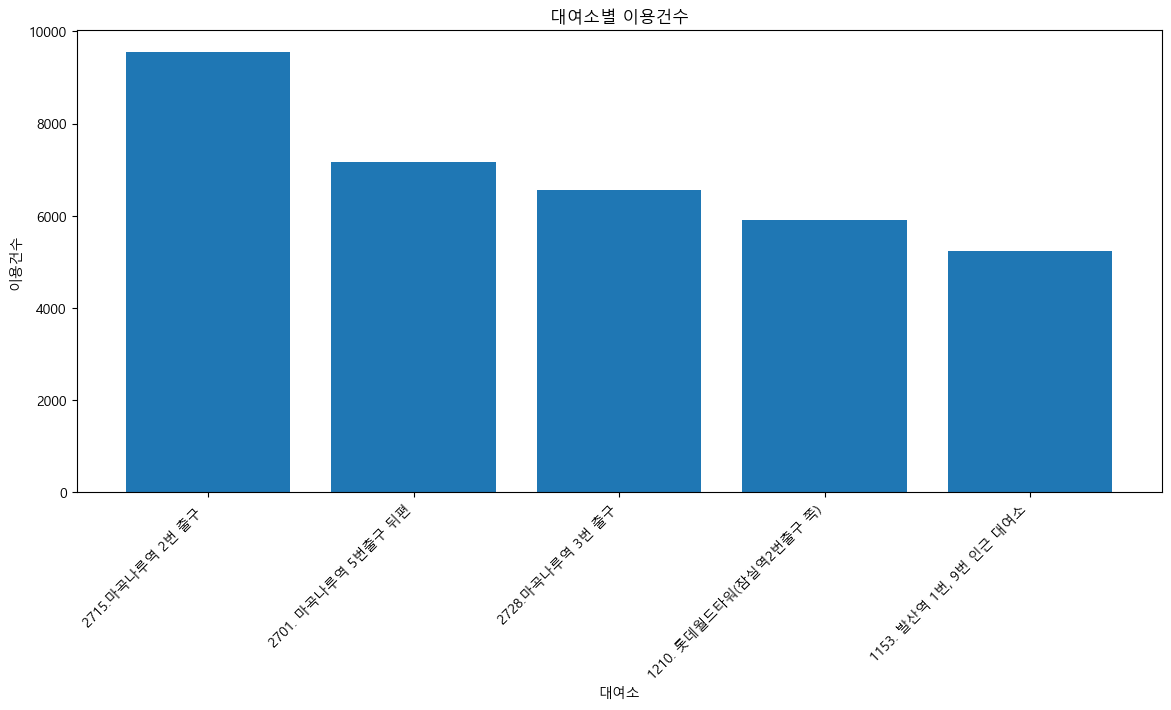

In [35]:
plt.figure(figsize = (14, 6))
plt.xlabel('대여소')
plt.ylabel('이용건수')
plt.title('대여소별 이용건수')
plt.bar(rent_day.index, rent_day.values)
plt.xticks(rotation=45, ha='right')
plt.show()